### Build A Basic Chatbot With Langgraph(GRAPH API)

In [12]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [13]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [14]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [15]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="openai/gpt-oss-20b")

In [16]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [17]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

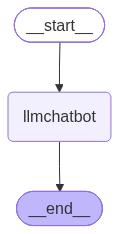

In [18]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [19]:
response=graph.invoke({"messages":"Hi"})

In [20]:
response["messages"][-1].content

'Hello! 👋 How can I help you today?'

In [21]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I’m doing great—thanks for asking. How about you? What’s on your mind today?


### Chatbot With Tool

In [22]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norweg

In [23]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [24]:
tools=[tool,multiply]

In [25]:
llm_with_tool=llm.bind_tools(tools)

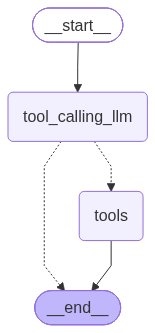

In [26]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
response=graph.invoke({"messages":"What is the recent ai news"})

In [28]:
response['messages'][-1].content

'{"query": "latest AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://cdt.org/insights/2026-state-and-federal-ai-legislation-updates", "title": "2026 State and Federal AI Legislation Updates", "content": "Senators Mark Kelly (AZ) and Jim Justice (WV) recently introduced the Senior Chatbot Protection Act of 2026. This bill would require rules similar to chatbot bills that have been introduced at the state level, such as “conspicuously disclose to the user that the chatbot is an artificial intelligence chatbot and not a human being” and create protocols for addressing users that may be expressing mental health crises. Unlike state level bills, this bill does not require that chatbot providers attempt to discern a user’s age, but rather instructs that older Americans be considered in the planning of chatbot safety protocols. The White House National Policy Framework for AI released in March 2026 also notes the importance of combating AI-

In [29]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_fb675404-33de-459b-9a38-52682a1ebfd3)
 Call ID: fc_fb675404-33de-459b-9a38-52682a1ebfd3
  Args:
    query: latest AI news 2026
    search_depth: advanced
    time_range: week
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://cdt.org/insights/2026-state-and-federal-ai-legislation-updates", "title": "2026 State and Federal AI Legislation Updates", "content": "Senators Mark Kelly (AZ) and Jim Justice (WV) recently introduced the Senior Chatbot Protection Act of 2026. This bill would require rules similar to chatbot bills that have been introduced at the state level, such as “conspic

In [30]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================

5 multiplied by 2 equals **10**.


### ReAct Agent Architecture

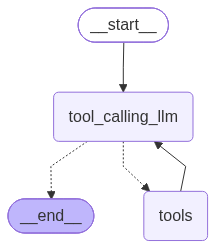

In [31]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_5334585c-7129-4b4c-9c3f-ea5b4d193b83)
 Call ID: fc_5334585c-7129-4b4c-9c3f-ea5b4d193b83
  Args:
    query: recent AI news 2026
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.linkedin.com/pulse/latest-ai-news-we-announced-april-2026-google-rom6e", "title": "The latest AI news we announced in April 2026", "content": "Our latest TPUs are built to power supercomputing with more efficiency. Powering the agentic era, our eighth-generation TPUs are designed specifically for the massive compute demands of agentic AI while maintaining a focus on en

### Adding Memory In Agentic Graph

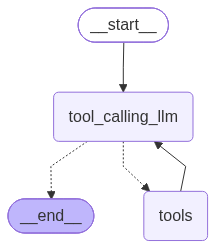

In [33]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Krish"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is Krish', additional_kwargs={}, response_metadata={}, id='84e1cc44-a311-4b42-9b62-99329a558aa4'),
  AIMessage(content='Hello Krish! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'User says "Hi my name is Krish". Likely they want to start conversation. We should respond politely. No tool usage needed.'}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 348, 'total_tokens': 399, 'completion_time': 0.052508126, 'completion_tokens_details': {'reasoning_tokens': 29}, 'prompt_time': 0.02464052, 'prompt_tokens_details': None, 'queue_time': 0.304377028, 'total_time': 0.077148646}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e2cb7a84ec', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a02552-f59c-7110-8494-bb150826c70b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 348, 'output_tokens': 5

In [35]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Your name is Krish.


### Streaming

In [36]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [37]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

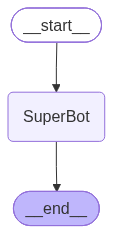

In [38]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

### Streaming

Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- values : This streams the full state of the graph after each node is called.
- updates : This streams updates to the state of the graph after each node is called.

In [39]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hey Krish! 👋 Great to meet you. Cricket’s an awesome sport—do you have a favourite team or player? Or maybe you’ve got a memorable match you love to talk about?', additional_kwargs={'reasoning_content': 'User says: "Hi,My name is Krish And I like cricket". They are greeting, telling name and interest. We should respond accordingly. The user wants a friendly response, maybe ask about cricket. Provide a friendly tone. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 101, 'prompt_tokens': 82, 'total_tokens': 183, 'completion_time': 0.12391483, 'completion_tokens_details': {'reasoning_tokens': 52}, 'prompt_time': 0.004796233, 'prompt_tokens_details': None, 'queue_time': 0.301954438, 'total_time': 0.128711063}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_334cc21c60', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a02562-cb98-7641-91a9-

In [40]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='5aec089b-f191-4df7-bf12-df9205737611'), AIMessage(content='Hey Krish! 👋 Great to meet you. Cricket’s an awesome sport—do you have a favourite team or player? Or maybe you’ve got a memorable match you love to talk about?', additional_kwargs={'reasoning_content': 'User says: "Hi,My name is Krish And I like cricket". They are greeting, telling name and interest. We should respond accordingly. The user wants a friendly response, maybe ask about cricket. Provide a friendly tone. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 101, 'prompt_tokens': 82, 'total_tokens': 183, 'completion_time': 0.12391483, 'completion_tokens_details': {'reasoning_tokens': 52}, 'prompt_time': 0.004796233, 'prompt_tokens_details': None, 'queue_time': 0.301954438, 'total_time': 0.128711063}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_334cc21c60

In [41]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hello Krish! 👋 Great to meet a cricket fan. How do you like the game? Are you into batting, bowling, or just enjoying watching matches? If you’ve got a favorite team or player, let me know—I’d love to hear more about your cricket interests!', additional_kwargs={'reasoning_content': 'User: "Hi, My name is Krish And I like cricket". We need to respond politely. Possibly ask about cricket or engage. Provide friendly response. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 103, 'prompt_tokens': 82, 'total_tokens': 185, 'completion_time': 0.120165197, 'completion_tokens_details': {'reasoning_tokens': 37}, 'prompt_time': 0.004004341, 'prompt_tokens_details': None, 'queue_time': 0.280043992, 'total_time': 0.124169538}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_fcc9b7b2df', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a02563-399e-7d

In [42]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='f7aad9ab-c55e-42b9-9e9b-bdfc05195d45'), AIMessage(content='Hello Krish! 👋 Great to meet a cricket fan. How do you like the game? Are you into batting, bowling, or just enjoying watching matches? If you’ve got a favorite team or player, let me know—I’d love to hear more about your cricket interests!', additional_kwargs={'reasoning_content': 'User: "Hi, My name is Krish And I like cricket". We need to respond politely. Possibly ask about cricket or engage. Provide friendly response. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 103, 'prompt_tokens': 82, 'total_tokens': 185, 'completion_time': 0.120165197, 'completion_tokens_details': {'reasoning_tokens': 37}, 'prompt_time': 0.004004341, 'prompt_tokens_details': None, 'queue_time': 0.280043992, 'total_time': 0.124169538}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_fc

In [43]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)
    

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a02564-1d8f-7670-b948-c2b53fd545bc', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='3ace75ef-a572-4c32-8caa-c8fc18baad39')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '01a02564-1d93-77c3-ac2d-d39add697185', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:3ca506ea-1fea-b7b4-d6bf-f3d18c819090'}, 'parent_ids': ['01a02564-1d8f-7670-b948-c2b53fd545bc']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':